In [29]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt
from rich.console import Console

from libdet import Hamiltonian
from detnqs.model import Backflow, RBM
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr, minsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [30]:
mol = gto.M(
    atom=
    '''
    N   0.53920000,  0.00000000,  0.0000000
    N   -0.539200000,  0.00000000,  0.0000000
    ''',
    # atom=
    # '''
    # O   0.00000000,  0.00000000,  0.00000000
    # H   0.75700000,  0.00000000,  0.58590000
    # H  -0.75700000,  0.00000000,  0.58590000
    # ''',
    # atom=
    # '''
    # Li   3.732, 0.25, 0.0
    # Li   2.0, 0.25, 0.0
    # O  2.866, -0.25, 0.0
    # ''',
    basis="sto-3g",
    unit="Angstrom",
    spin=0,
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -109.099941428008

solver = fci.direct_spin1.FCI(mol)
solver.nroots = 2
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
s2, mult = fci.spin_op.spin_square(ci[0], norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -107.488973088654
FCI energy : -107.640233152150
S^2  : 0.000000


In [31]:
model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64, ))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=32,
    alpha="adaptive",
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
)

steps = 1000

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

-----------------------------------------------------------------------
 Step          Energy      |E-E0|        Var     Acc     ESS    SR cond
-----------------------------------------------------------------------
    0   -107.48897180    1.51e-01   3.30e-01   0.001   0.514   1.35e+00
   10   -107.61098528    2.92e-02   8.28e-03   0.071   0.471   3.99e+01
   20   -107.62871803    1.15e-02   1.61e-02   0.128   0.312   5.30e+01
   30   -107.63471625    5.52e-03   8.67e-03   0.193   0.237   7.52e+01
   40   -107.63740459    2.83e-03   7.52e-03   0.200   0.188   9.76e+01
   50   -107.63869386    1.54e-03   3.70e-03   0.222   0.164   1.11e+02
   60   -107.63931741    9.16e-04   2.63e-03   0.282   0.129   1.07e+02
   70   -107.63966219    5.71e-04   1.87e-03   0.296   0.103   1.27e+02
   80   -107.63982014    4.13e-04   1.17e-03   0.326   0.101   1.12e+02
   90   -107.63993812    2.95e-04   1.02e-03   0.365   0.068   1.35e+02
  100   -107.64003183    2.01e-04   7.65e-04   0.393   0.055   1

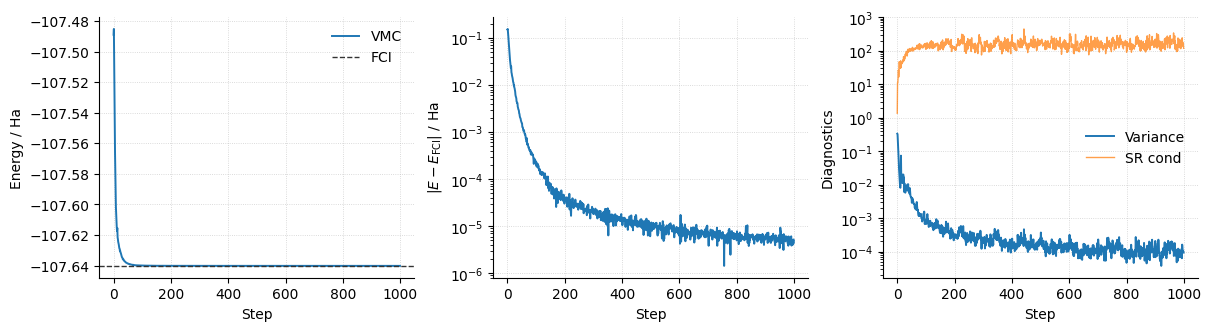

In [32]:
METRICS = {
    "step": ("Step", "5d"),
    "energy": ("Energy", "14.8f"),
    "error": ("|E-E0|", "10.2e"),
    "variance": ("Var", "9.2e"),
    "accept": ("Acc", "6.3f"),
    "ess_frac": ("ESS", "6.3f"),
    "sr_cond": ("SR cond", "9.2e"),
}

width = {k: int(fmt[:-1].split(".")[0]) for k, (_, fmt) in METRICS.items()}

header = "  ".join(f"{label:>{width[k]}}" for k, (label, _) in METRICS.items())
line = "-" * len(header)

print(line, header, line, sep="\n")

vmc = VMC.init(state, optimizer)
history = []
total_times = {}

for step in range(steps):
    stats = vmc.step()
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(dict(stats))

    for k, v in stats.items():
        if k.startswith("time_"):
            name = k.removeprefix("time_")
            total_times[name] = total_times.get(name, 0.0) + float(v)

    if step % 10 == 0 or step == steps - 1:
        row = "  ".join(
            f"{int(stats.get(k, 0)):{fmt}}"
            if fmt.endswith("d")
            else f"{float(stats.get(k, 0.0)):{fmt}}"
            for k, (_, fmt) in METRICS.items()
        )
        print(row)

print(line)

if total_times:
    items = [(k, v) for k, v in total_times.items() if k != "total"]
    items = sorted(items, key=lambda kv: kv[1], reverse=True)
    print("Time:", "  ".join(f"{k}={v:.2f}s" for k, v in items))
    print(line)

hist = {k: np.asarray([s.get(k, np.nan) for s in history]) for k in METRICS}
x = hist["step"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

axes[0].plot(x, hist["energy"], lw=1.4, label="VMC")
axes[0].axhline(e_fci, ls="--", lw=1.0, c="0.2", label="FCI")
axes[0].set(xlabel="Step", ylabel="Energy / Ha")
axes[0].legend(frameon=False)

axes[1].semilogy(x, np.maximum(hist["error"], 1e-16), lw=1.4)
axes[1].set(xlabel="Step", ylabel=r"$|E-E_\mathrm{FCI}|$ / Ha")

axes[2].semilogy(x, np.maximum(hist["variance"], 1e-16), lw=1.4, label="Variance")
if "sr_cond" in hist:
    axes[2].semilogy(x, hist["sr_cond"], lw=1.0, alpha=0.75, label="SR cond")
axes[2].set(xlabel="Step", ylabel="Diagnostics")
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(True, ls=":", lw=0.6, alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()